In [1]:
# jax.config.update("jax_enable_x64", True)
from pathlib import Path

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import xarray as xr
from context_flux_no.models.hyperfluxfno import ViTContextHyperFluxFNO
from context_flux_no.training import PDEDataset
from context_flux_no.training.io import load_model
from context_flux_no.training.loader import ContextSegmentLoader
from jaxtyping import Array, Float
from orbax.checkpoint import v1 as ocp


# jax.config.update("jax_captured_constants_report_frames", -1)


## Import data and run the model

In [2]:
# jax.config.update("jax_enable_x64", True)

datadir = Path("./data")
dataset_xr = xr.load_dataset(datadir / "cubic_no_source_large_train.hdf5")
# dataset_xr = xr.open_mfdataset(
#     sorted(list(datadir.glob("cubic_no_source_large_train_seed=*.hdf5"))),
#     combine="nested",
#     concat_dim="pde",
#     engine="h5netcdf",
# )
dataset_xr

<xarray.Dataset> Size: 40GB
Dimensions:  (pde: 1000, ic: 100, t: 1001, dim: 1, x: 100, param: 3)
Coordinates:
  * t        (t) float64 8kB 0.0 0.0005 0.001 0.0015 ... 0.4985 0.499 0.4995 0.5
  * x        (x) float64 800B 0.005 0.015 0.025 0.035 ... 0.975 0.985 0.995
  * dim      (dim) <U1 4B 'u'
  * param    (param) <U1 12B 'a' 'b' 'c'
Dimensions without coordinates: pde, ic
Data variables:
    values   (pde, ic, t, dim, x) float32 40GB 0.3343 0.219 ... -0.4966 -0.5188
    coeffs   (pde, param) float32 12kB -0.8828 -0.9787 ... -0.5751 -0.03708

/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/training/dataset.py:33: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return cls(u, t, x, coeffs, dim_names, coeff_names)
/home/jhko725/.local/share/uv/python/cpython-3.12.9-linux-x86_64-gnu/lib/python3.12/dataclasses.py:1588: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return obj.__class__(**changes)


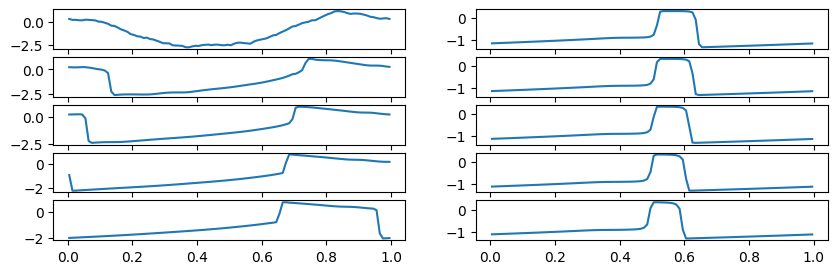

In [3]:
# Do the downsampling before on the dask arrays to make things speedier
dataset_train, dataset_test = (
    PDEDataset.from_xarray(dataset_xr).downsample_time(10).split_by_time(80)
)

fig, axes = plt.subplots(5, 2, figsize=(10, 3))
for i in range(axes.shape[0]):
    axes[i, 0].plot(dataset_train.x, dataset_train.u[0, 0, i * 4, 0])
    axes[i, 1].plot(dataset_test.x, dataset_test.u[0, 0, i * 4, 0])

In [4]:
def loss_fn(
    model: ContextSegmentLoader, batch: tuple[Float[Array, "..."]]
) -> tuple[Float[Array, ""], dict]:
    context, u, dt, dx = batch
    u0, u1 = u[:, 0], u[:, 1]
    u1_pred = eqx.filter_vmap(
        lambda context_, u0_: model(context_, u0_, dt, dx, key=jax.random.key(0))
    )(context, u0)
    return jnp.mean((u1 - u1_pred) ** 2), None


def train(
    model: ViTContextHyperFluxFNO,
    dataloader: ContextSegmentLoader,
    optimizer: optax.GradientTransformation,
    loss_fn,
    max_steps: int,
):
    loss_grad_fn = eqx.filter_value_and_grad(loss_fn, has_aux=True)

    @eqx.filter_jit
    def train_step(model_, loader_state_, opt_state_):
        batch, loader_state_next = dataloader.load_batch(loader_state_)
        (loss, aux), grads = loss_grad_fn(model_, batch)
        updates, opt_state_next = optimizer.update(
            grads, opt_state_, eqx.filter(model_, eqx.is_array)
        )
        model_ = eqx.apply_updates(model_, updates)
        return loss, aux, model_, loader_state_next, opt_state_next

    loader_state = dataloader.init()
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

    loss_history = []
    for i in range(max_steps):
        loss, aux, model, loader_state, opt_state = train_step(
            model, loader_state, opt_state
        )

        loss_scalar = loss.item()
        print(f"Step: {i}: loss = {loss_scalar}")
        loss_history.append(loss_scalar)
    return model, jnp.asarray(loss_history)

In [ ]:
model = ViTContextHyperFluxFNO(
    data_dim=1,
    depth=4,
    frequency_modes=16,
    lift_dim=96,
    context_embed_dim=96,
    stencil_size=(2, 1),
    key=jax.random.key(0),
)

In [ ]:
model

In [ ]:
checkpointer = ocp.training.Checkpointer(
    Path("./checkpoints/test").resolve(),
    preservation_policy=ocp.training.preservation_policies.BestN(
        get_metric_fn=lambda metrics: metrics["train_loss"],
        reverse=True,
        n=1,
    ),
)
with checkpointer as ckptr:
    ckptr.save_pytree(0, eqx.filter(model, eqx.is_array))

In [ ]:
loader = ContextSegmentLoader(
    dataset_train, context_size=20, segment_length=2, batch_size=1024
)
batch, _ = loader.load_batch(loader.init())

In [ ]:
loss_fn(model, batch)

In [ ]:
# optimizer = optax.adamw(
#     optax.schedules.warmup_cosine_decay_schedule(0.0, 5e-4, 500, 4500, 0.0)
# )
optimizer = optax.adamw(1e-4)
model, loss_history = train(model, loader, optimizer, loss_fn, max_steps=5000)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(loss_history)
ax.set_yscale("log")

## Load model from checkpoint and evaluate performance

In [20]:
modelpath = Path("./checkpoints/test")
model_load = load_model(modelpath)

In [6]:
loader_test = ContextSegmentLoader(
    dataset_test, context_size=20, segment_length=20, batch_size=32
)
batch_test, _ = loader_test.load_batch(loader_test.init())

In [7]:
context_test, u_test, dt, dx = batch_test
context_test.shape

(32, 20, 1, 100)

In [21]:
sample_idx = 0
model_test = eqx.nn.inference_mode(model_load)


def f_inner(u0, _):
    u1 = model_test(context_test[sample_idx], u0, dt, dx, key=jax.random.key(0))
    return u1, u1


_, u_test_pred = jax.lax.scan(
    f_inner,
    u_test[sample_idx][0],
    u_test[sample_idx],
)

Text(0.5, 1.0, 'Seen initial condition, extrapolation (rollout = $10\\Delta t$)')

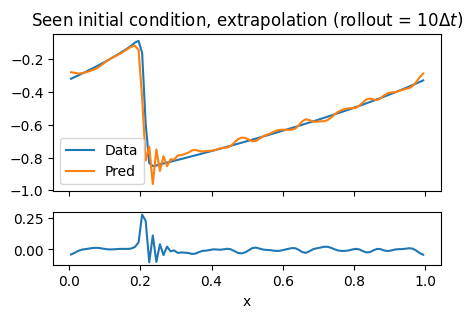

In [22]:
time_idx = 10
fig, axes = plt.subplots(2, 1, figsize=(5, 3), height_ratios=(3, 1), sharex=True)
axes[0].plot(dataset_test.x, u_test[sample_idx][time_idx, 0], label="Data")
axes[0].plot(dataset_test.x, u_test_pred[time_idx, 0], label="Pred")
axes[0].legend()

axes[1].plot(dataset_test.x, u_test[sample_idx][time_idx, 0] - u_test_pred[time_idx, 0])

axes[-1].set_xlabel("x")
axes[0].set_title(r"Seen initial condition, extrapolation (rollout = $10\Delta t$)")

In [23]:
dataset_xr = xr.load_dataset(datadir / "cubic_no_source_test.hdf5")
dataset_ood_interp, dataset_ood_extrap = (
    PDEDataset.from_xarray(dataset_xr).downsample_time(10).split_by_time(80)
)

In [24]:
loader_ood = ContextSegmentLoader(
    dataset_ood_interp, context_size=20, segment_length=20, batch_size=32
)
batch_ood, _ = loader_ood.load_batch(loader_ood.init())

In [25]:
sample_idx = 30

context_ood, u_ood, dt, dx = batch_ood


def f_inner(u0, _):
    u1 = model_test(context_ood[sample_idx], u0, dt, dx, key=jax.random.key(0))
    return u1, u1


_, u_ood_pred = jax.lax.scan(
    f_inner,
    u_ood[sample_idx][0],
    u_ood[sample_idx],
)

Text(0.5, 1.0, 'Unseen initial condition, interpolation (rollout = $10\\Delta t$)')

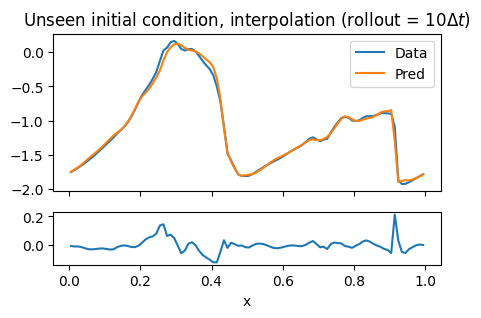

In [27]:
time_idx = 10
fig, axes = plt.subplots(2, 1, figsize=(5, 3), height_ratios=(3, 1), sharex=True)
axes[0].plot(dataset_ood_interp.x, u_ood[sample_idx][time_idx, 0], label="Data")
axes[0].plot(dataset_ood_interp.x, u_ood_pred[time_idx, 0], label="Pred")
axes[0].legend()

axes[1].plot(
    dataset_ood_interp.x, u_ood[sample_idx][time_idx, 0] - u_ood_pred[time_idx, 0]
)

axes[-1].set_xlabel("x")
axes[0].set_title(r"Unseen initial condition, interpolation (rollout = $10\Delta t$)")